In [1]:
from data_utils import *
from import_pkgs import *

In [2]:
suffix = "-00000.nc"       

test_base_dir = Path(f"/glade/derecho/scratch/yifanc17/archive/{test_case}/atm/hist/") 
test_atm_prefix = f"{test_case}.cam.h1"         

feb_mar_dates = pd.date_range("2024-02-01", "2024-03-31", freq="D")

test_atm_files = [
    test_base_dir / f"{test_atm_prefix}.{d.strftime('%Y-%m-%d')}{suffix}"
    for d in feb_mar_dates
]

In [3]:
suffix = "-00000.nc"       

rural_base_dir = Path(f"/glade/derecho/scratch/yifanc17/archive/{rural_case}/atm/hist/") 
rural_atm_prefix = f"{rural_case}.cam.h1"         

feb_mar_dates = pd.date_range("2024-02-01", "2024-03-31", freq="D")

rural_atm_files = [
    rural_base_dir / f"{rural_atm_prefix}.{d.strftime('%Y-%m-%d')}{suffix}"
    for d in feb_mar_dates
]

In [4]:
test_atm_daily=xr.open_mfdataset(test_atm_files)
rural_atm_daily=xr.open_mfdataset(rural_atm_files)

/glade/derecho/scratch/yifanc17/tmp/ipykernel_10673/2823017729.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  test_atm_daily=xr.open_mfdataset(test_atm_files)
/glade/derecho/scratch/yifanc17/tmp/ipykernel_10673/2823017729.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  rural_atm_daily=xr.open_mfdataset

In [5]:
lnd_sel_vars=["FSH","TSA","RAIN","SNOW","FSA","FIRA","RH2M","Q2M","TSKIN","LWup","SWup"]
atm_meteo_vars=["U","V","T","Q","PMID","PS","PDELDRY"]
atm_conc_vars=["PM25", "NO", "NO2", "NOY", "O3", "CO", "HNO3", "SO2", "PAN", "bc_tot", "pom_tot", "so4_tot", "dst_tot", "soa_tot"]
atm_chem_vars=["O3_Prod","O3_Loss", "Ox_Prod", "Ox_Loss", "O3_alkenes", "RO2_NO_sum", "RO2_HO2_sum", "RO2_NO3_sum", "RO2_RO2_sum", 
               "RCO2_NO2_sum", "r_OH_O3", "r_HO2_O3", "r_O1D_H2O", "r_OH_O", "r_jno2", "jno2", "jo3_a", "LNO_PROD", "LNO_COL_PROD", "SO2_CLXF", "AODVISdn"]
# surface emission flux
atm_emis_vars=["SFNO", "SFNO2", "SFSO2", "SFCO", "SFISOP", "SFSVOC", "SFMTERP", "SFTOLUENE", "SFXYLENES", "SFbc_a4",
               "SFpom_a4", "SFso4_a1", "SFso4_a2", "SFdst_a1", "SFdst_a2", "SFdst_a3", "SFncl_a1", "SFncl_a2", "SFncl_a3", "SFnum_a1", "SFnum_a2", "SFnum_a3", "SFnum_a4"]
atm_sink_vars=["DF_O3", "DF_HNO3", "DF_CO", "WD_HNO3", "WD_H2O2", "WD_H2SO4", "WD_H2SO4"]

In [6]:
atm_sel_vars=atm_meteo_vars+atm_conc_vars+atm_chem_vars+atm_emis_vars+atm_sink_vars

In [7]:
test_atm_daily_sel=test_atm_daily[atm_sel_vars]
rural_atm_daily_sel=rural_atm_daily[atm_sel_vars]

In [8]:
k_B = 1.380649e-23 
g = 9.80665         
Mw_air = 28.97e-3   
Mw_O3 = 48.00e-3    
Seconds_per_day = 86400.0

def analyze_daily_budget(ds, lev_surf=-1):
    o3 = ds["O3"].isel(lev=lev_surf) * 1e9  # mol/mol -> ppb
    T = ds["T"].isel(lev=lev_surf)
    P = ds["PMID"].isel(lev=lev_surf)
    dP = ds["PDELDRY"].isel(lev=lev_surf)

    prod = ds["O3_Prod"].isel(lev=lev_surf) 
    loss = ds["O3_Loss"].isel(lev=lev_surf) 
    
    dep_flux = ds["DF_O3"] 

    n_air_cm3 = (P / (k_B * T)) * 1e-6 
    
    # net chem rate (molec/cm3/s)
    net_chem_rate = prod - loss
    
    # ppb/s -> ppb/day
    t_chem = (net_chem_rate / n_air_cm3) * 1e9 * Seconds_per_day

    m_air = dP / g  
    
    # flux (kg/m2/s) -> mixing ratio trend (kg_O3/kg_Air/s)
    dep_rate_kg = -dep_flux / m_air 
    
    t_dep = dep_rate_kg * (Mw_air / Mw_O3) * 1e9 * Seconds_per_day

    o3_tomorrow = o3.shift(time=-1)
    
    dO3_dt_obs = o3_tomorrow - o3 # ppb/day
    
    t_transport = dO3_dt_obs - t_chem - t_dep

    results = xr.Dataset({
        "Chem_ppb_day": t_chem,
        "Dep_ppb_day": t_dep,
        "Transport_ppb_day": t_transport,
        "Net_Change_Obs": dO3_dt_obs,
        "O3_Concentration": o3
    }).isel(time=slice(0, -1))
    
    return results

In [9]:
budget_urban = analyze_daily_budget(test_atm_daily_sel)
budget_rural = analyze_daily_budget(rural_atm_daily_sel)
budget_urban, budget_rural = xr.align(budget_urban, budget_rural, join="inner")
urban_impact = budget_urban - budget_rural

urban_impact = urban_impact.rename({
    "Chem_ppb_day": "Delta_Chem",          
    "Dep_ppb_day": "Delta_Dep",            
    "Transport_ppb_day": "Delta_Transport", 
    "Net_Change_Obs": "Delta_Net_Change",
    "O3_Concentration": "Delta_O3_Conc"    
})

In [10]:
def calculate_relative_contrib(impact_ds):
    mean_chem = impact_ds["Delta_Chem"].mean(dim="time")
    mean_dep = impact_ds["Delta_Dep"].mean(dim="time")
    mean_trans = impact_ds["Delta_Transport"].mean(dim="time")
    net_change = impact_ds["Delta_Net_Change"].mean(dim="time")
    
    turnover = abs(mean_chem) + abs(mean_dep) + abs(mean_trans)
    
    frac_chem = mean_chem / turnover
    frac_dep = mean_dep / turnover
    frac_trans = mean_trans / turnover

    return frac_chem, frac_dep, frac_trans, net_change

mean_chem, mean_dep, mean_trans, net_change = calculate_relative_contrib(urban_impact)

In [25]:
ds=[net_change, mean_chem, mean_dep, mean_trans]

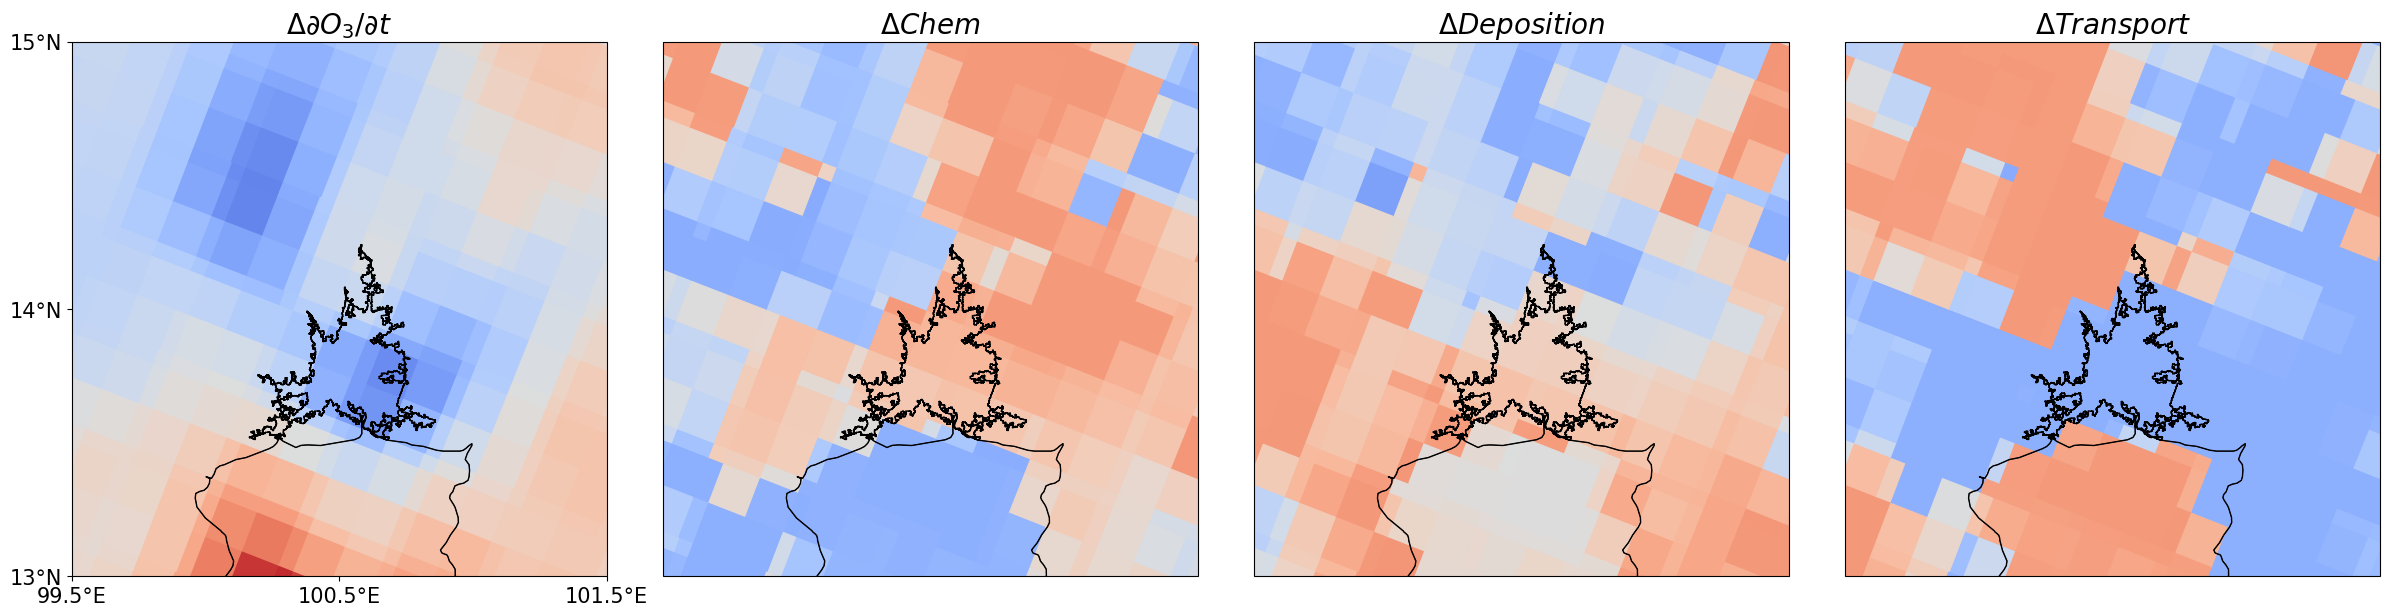

In [24]:
fig, axs=plt.subplots(1,4,figsize=(24,6),subplot_kw=dict(projection=ccrs.PlateCarree()))

Plot_2D(ds[0],
            scrip_file=MUSICA_scrip_path,
            cmap='coolwarm',
            cmin=-0.5,
            cmax=0.5,
            lat_range=(13,15),
            lon_range=(99.5,101.5),
            ax=axs[0],
            colorbar=False,
            grid_line=False,
            font_family="DejaVu Sans")

for i in range(1,4):
    Plot_2D(ds[i],
            scrip_file=MUSICA_scrip_path,
            cmap='coolwarm',
            cmin=-1,
            cmax=1,
            lat_range=(13,15),
            lon_range=(99.5,101.5),
            ax=axs[i],
            colorbar=False,
            grid_line=False,
            lonlat_line=False,
            label_size=12,
            font_family="DejaVu Sans")

for i in range(4):
    axs[i].add_geometries([bak_shapefile], ccrs.PlateCarree(), 
                   edgecolor='black', facecolor='none', linewidth=1, zorder=200)
    axs[i].coastlines()

axs[0].set_title(r"$\Delta \partial O_3/\partial t$",fontsize=20,fontfamily="DejaVu Sans")
axs[1].set_title(r"$\Delta Chem$",fontsize=20,fontfamily="DejaVu Sans")
axs[2].set_title(r"$\Delta Deposition$",fontsize=20,fontfamily="DejaVu Sans")
axs[3].set_title(r"$\Delta Transport$",fontsize=20,fontfamily="DejaVu Sans")
plt.tight_layout()
fig.savefig(PLOT_PATH+'JGR_Fig10a_Bangkok_O3_decomp.png',dpi=300,bbox_inches='tight')

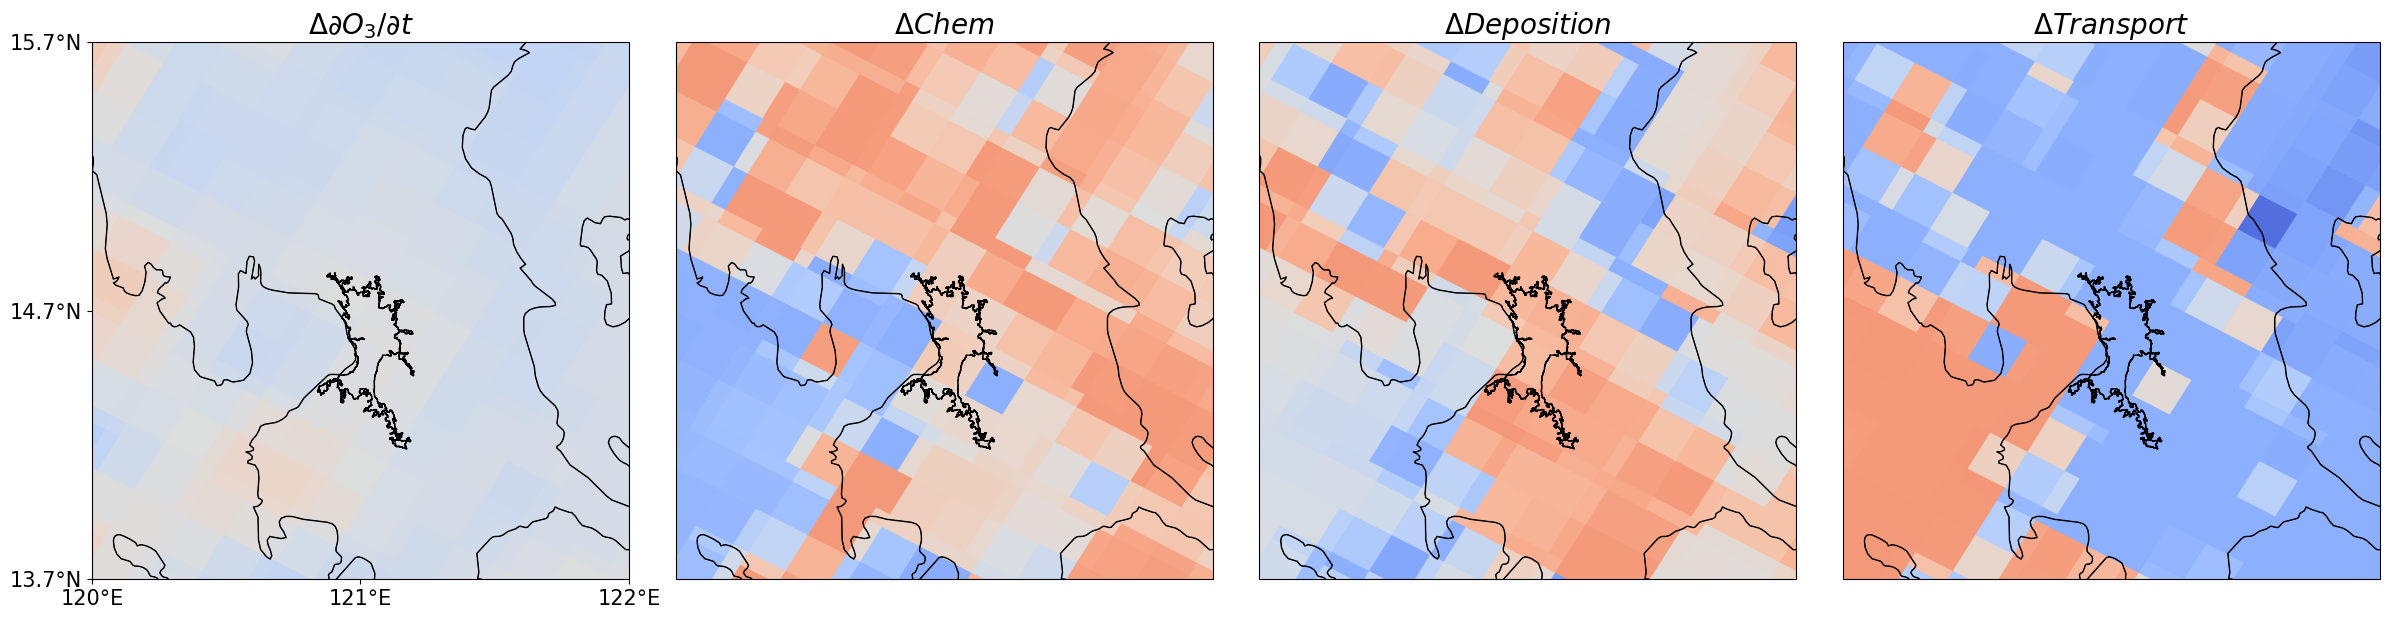

In [23]:
fig, axs=plt.subplots(1,4,figsize=(24,6),subplot_kw=dict(projection=ccrs.PlateCarree()))

Plot_2D(ds[0],
            scrip_file=MUSICA_scrip_path,
            cmap='coolwarm',
            cmin=-0.5,
            cmax=0.5,
            lat_range=(13.7,15.7),
            lon_range=(120,122),
            ax=axs[0],
            colorbar=False,
            grid_line=False,
            font_family="DejaVu Sans")

for i in range(1,4):
    Plot_2D(ds[i],
            scrip_file=MUSICA_scrip_path,
            cmap='coolwarm',
            cmin=-1,
            cmax=1,
            lat_range=(13.7,15.7),
            lon_range=(120,122),
            ax=axs[i],
            colorbar=False,
            grid_line=False,
            lonlat_line=False,
            label_size=12,
            font_family="DejaVu Sans")

for i in range(4):
    axs[i].add_geometries([mal_shapefile], ccrs.PlateCarree(), 
                   edgecolor='black', facecolor='none', linewidth=1, zorder=200)
    axs[i].coastlines()

axs[0].set_title(r"$\Delta \partial O_3/\partial t$",fontsize=20,fontfamily="DejaVu Sans")
axs[1].set_title(r"$\Delta Chem$",fontsize=20,fontfamily="DejaVu Sans")
axs[2].set_title(r"$\Delta Deposition$",fontsize=20,fontfamily="DejaVu Sans")
axs[3].set_title(r"$\Delta Transport$",fontsize=20,fontfamily="DejaVu Sans")
plt.tight_layout()
fig.savefig(PLOT_PATH+'JGR_Fig10b_Manila_O3_decomp.png',dpi=300,bbox_inches='tight')

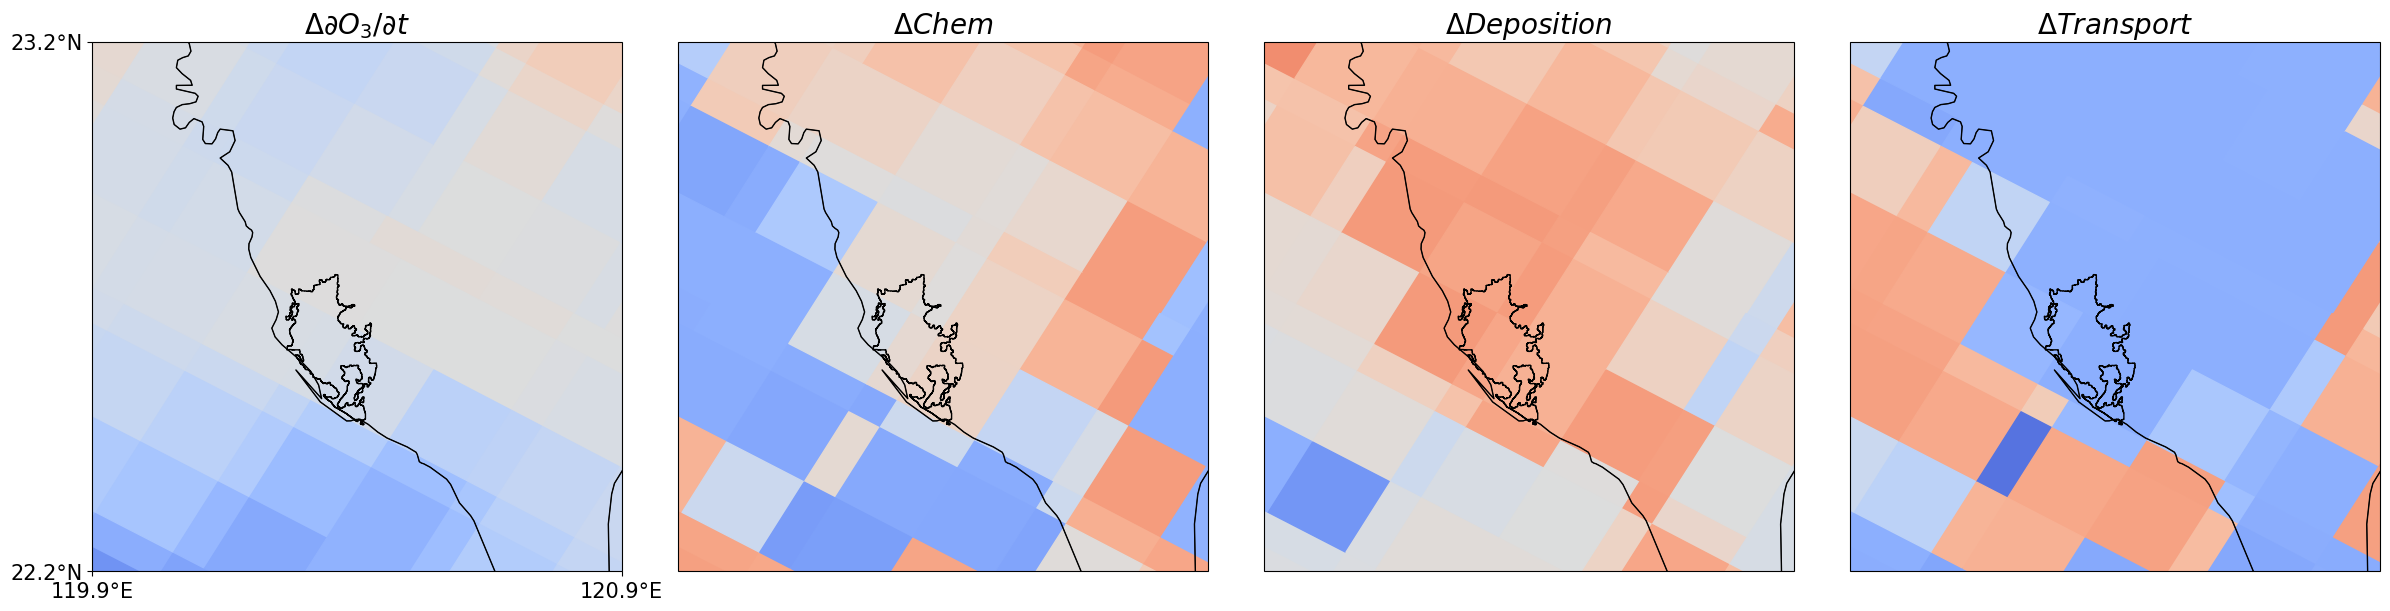

In [21]:
fig, axs=plt.subplots(1,4,figsize=(24,6),subplot_kw=dict(projection=ccrs.PlateCarree()))

Plot_2D(ds[0],
            scrip_file=MUSICA_scrip_path,
            cmap='coolwarm',
            cmin=-0.5,
            cmax=0.5,
            lat_range=(22.2,23.2),
            lon_range=(119.9,120.9),
            ax=axs[0],
            colorbar=False,
            grid_line=False,
            font_family="DejaVu Sans")

for i in range(1,4):
    Plot_2D(ds[i],
            scrip_file=MUSICA_scrip_path,
            cmap='coolwarm',
            cmin=-1,
            cmax=1,
            lat_range=(22.2,23.2),
            lon_range=(119.9,120.9),
            ax=axs[i],
            colorbar=False,
            grid_line=False,
            lonlat_line=False,
            label_size=12,
            font_family="DejaVu Sans")

for i in range(4):
    axs[i].add_geometries([kao_shapefile], ccrs.PlateCarree(), 
                   edgecolor='black', facecolor='none', linewidth=1, zorder=200)
    axs[i].coastlines()

axs[0].set_title(r"$\Delta \partial O_3/\partial t$",fontsize=20,fontfamily="DejaVu Sans")
axs[1].set_title(r"$\Delta Chem$",fontsize=20,fontfamily="DejaVu Sans")
axs[2].set_title(r"$\Delta Deposition$",fontsize=20,fontfamily="DejaVu Sans")
axs[3].set_title(r"$\Delta Transport$",fontsize=20,fontfamily="DejaVu Sans")
plt.tight_layout()
fig.savefig(PLOT_PATH+'JGR_Fig10c_Kaohisung_O3_decomp.png',dpi=300,bbox_inches='tight')

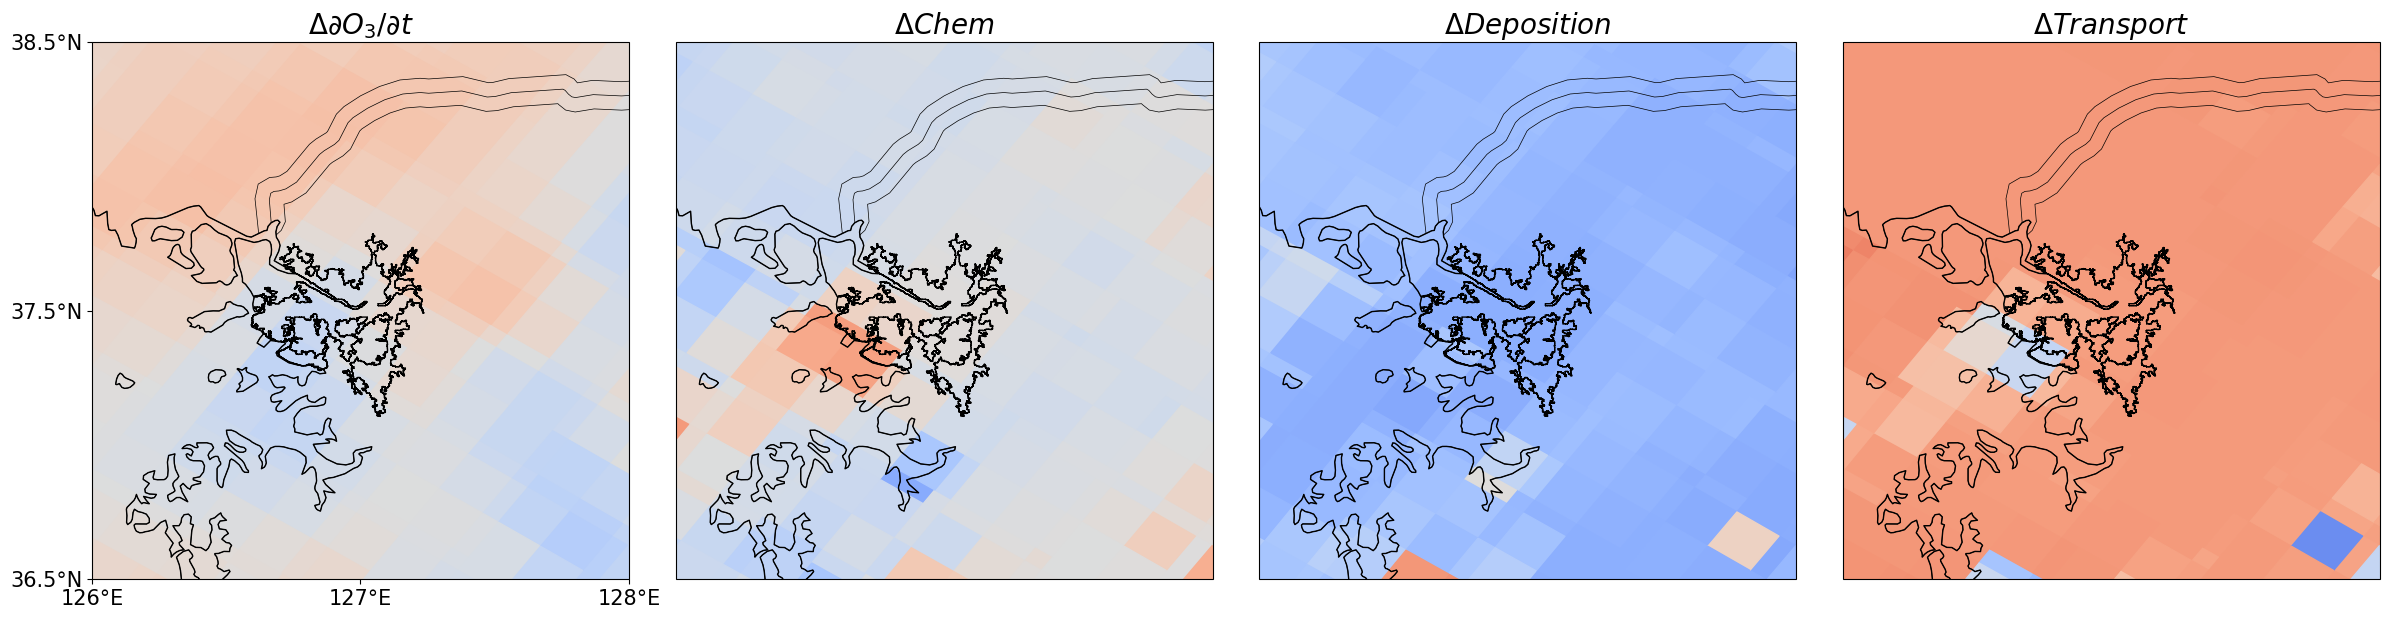

In [22]:
fig, axs=plt.subplots(1,4,figsize=(24,6),subplot_kw=dict(projection=ccrs.PlateCarree()))

Plot_2D(ds[0],
            scrip_file=MUSICA_scrip_path,
            cmap='coolwarm',
            cmin=-0.5,
            cmax=0.5,
            lat_range=(36.5,38.5),
            lon_range=(126, 128),
            ax=axs[0],
            colorbar=False,
            grid_line=False,
            font_family="DejaVu Sans")

for i in range(1,4):
    Plot_2D(ds[i],
            scrip_file=MUSICA_scrip_path,
            cmap='coolwarm',
            cmin=-1,
            cmax=1,
            lat_range=(36.5,38.5),
            lon_range=(126, 128),
            ax=axs[i],
            colorbar=False,
            grid_line=False,
            lonlat_line=False,
            label_size=12,
            font_family="DejaVu Sans")

for i in range(4):
    axs[i].add_geometries([seo_shapefile], ccrs.PlateCarree(), 
                   edgecolor='black', facecolor='none', linewidth=1, zorder=200)
    axs[i].coastlines()

axs[0].set_title(r"$\Delta \partial O_3/\partial t$",fontsize=20,fontfamily="DejaVu Sans")
axs[1].set_title(r"$\Delta Chem$",fontsize=20,fontfamily="DejaVu Sans")
axs[2].set_title(r"$\Delta Deposition$",fontsize=20,fontfamily="DejaVu Sans")
axs[3].set_title(r"$\Delta Transport$",fontsize=20,fontfamily="DejaVu Sans")
plt.tight_layout()
fig.savefig(PLOT_PATH+'JGR_Fig10d_Seoul_O3_decomp.png',dpi=300,bbox_inches='tight')

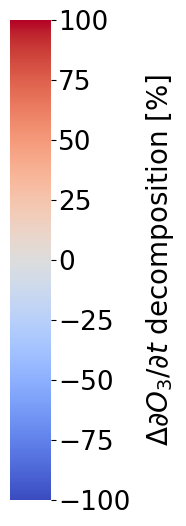

In [34]:
fig,cb=create_standalone_colorbar(-100, 100, cmap='coolwarm', 
                             label=r"$\Delta \partial O_3/\partial t$ decomposition [%]", label_fontsize=20,
                             tick_values=None, tick_fontsize=19,
                             figsize=(0.45, 16), 
                             orientation='vertical',
                             ticklocation='right',
                             extend='neither')

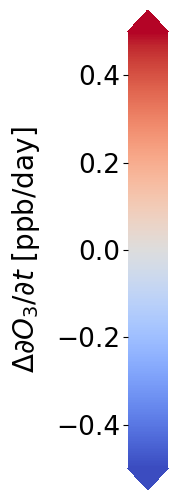

In [33]:
fig,cb=create_standalone_colorbar(-0.5, 0.5, cmap='coolwarm', 
                             label=r"$\Delta \partial O_3/\partial t$ [ppb/day]", label_fontsize=20,
                             tick_values=None, tick_fontsize=19,
                             figsize=(0.45, 16), 
                             orientation='vertical',
                             ticklocation='left',
                             extend='both')